<a href="https://colab.research.google.com/github/Atikahdr/Elevvo_ML_StudentPerformanceFactors/blob/main/Student_Performance_Factors_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Connect G-Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 3. Load Data

In [4]:
# Loading the dataset
student_data = pd.read_csv('/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/StudentPerformanceFactors/StudentPerformanceFactors.csv')

In [5]:
# First 5 rows of the dataset
student_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# 4. Data Overview

In [6]:
# Display Info
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [7]:
# Number of rows and columns
student_data.shape

(6607, 20)

In [8]:
# Display Summay Statistics
print("Summary Statistics of Numerical")
display(student_data.describe().T)

Summary Statistics of Numerical


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [9]:
print("Summary Statistics of Categorical")
display(student_data.describe(include='object').T)

Summary Statistics of Categorical


,count,unique,top,freq
Parental_Involvement,6607,3,Medium,3362
Access_to_Resources,6607,3,Medium,3319
Extracurricular_Activities,6607,2,Yes,3938
Motivation_Level,6607,3,Medium,3351
Internet_Access,6607,2,Yes,6108
Family_Income,6607,3,Low,2672
Teacher_Quality,6529,3,Medium,3925
School_Type,6607,2,Public,4598
Peer_Influence,6607,3,Positive,2638
Learning_Disabilities,6607,2,No,5912


In [10]:
# Checking Duplicated
student_data.duplicated().sum()

np.int64(0)

In [11]:
# Checking Null
student_data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [12]:
missing_value = pd.DataFrame({
    'Missing Value %': (student_data.isnull().sum() / len(student_data)) * 100
    }).sort_values(by='Missing Value %', ascending=False)

missing_value[missing_value['Missing Value %'] > 0]

,Missing Value %
Parental_Education_Level,1.362192
Teacher_Quality,1.180566
Distance_from_Home,1.014076


# 5. Cleaning Data

In [13]:
# Fill missing values using mode
cols = ['Parental_Education_Level',	'Teacher_Quality', 'Distance_from_Home']

for col in cols:
    student_data[col] = student_data[col].fillna(student_data[col].mode()[0])


In [14]:
student_data.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


# 6. EDA (Exploratory Data Analysis)

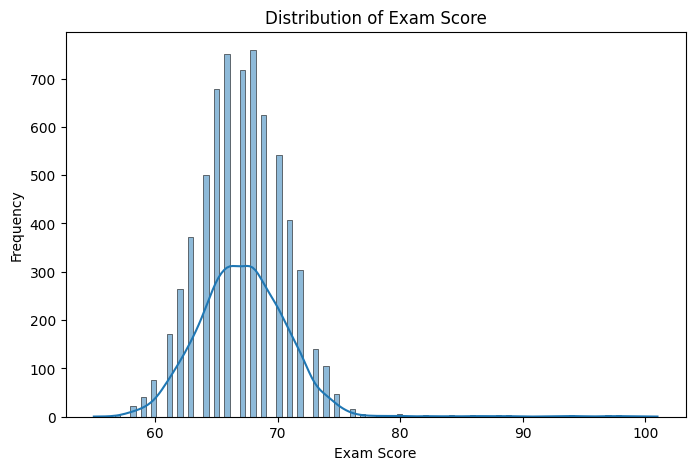

In [15]:
# Target Visualization
plt.figure(figsize=(8,5))
sns.histplot(student_data['Exam_Score'], kde=True)
plt.title('Distribution of Exam Score')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Numcerical of Columns
num_cols = student_data.select_dtypes(include='int64').columns

# Categoriccal of Columns
cat_cols = student_data.select_dtypes(include='object').columns

num_cols, cat_cols

(Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
        'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
       dtype='object'),
 Index(['Parental_Involvement', 'Access_to_Resources',
        'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
        'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
        'Learning_Disabilities', 'Parental_Education_Level',
        'Distance_from_Home', 'Gender'],
       dtype='object'))

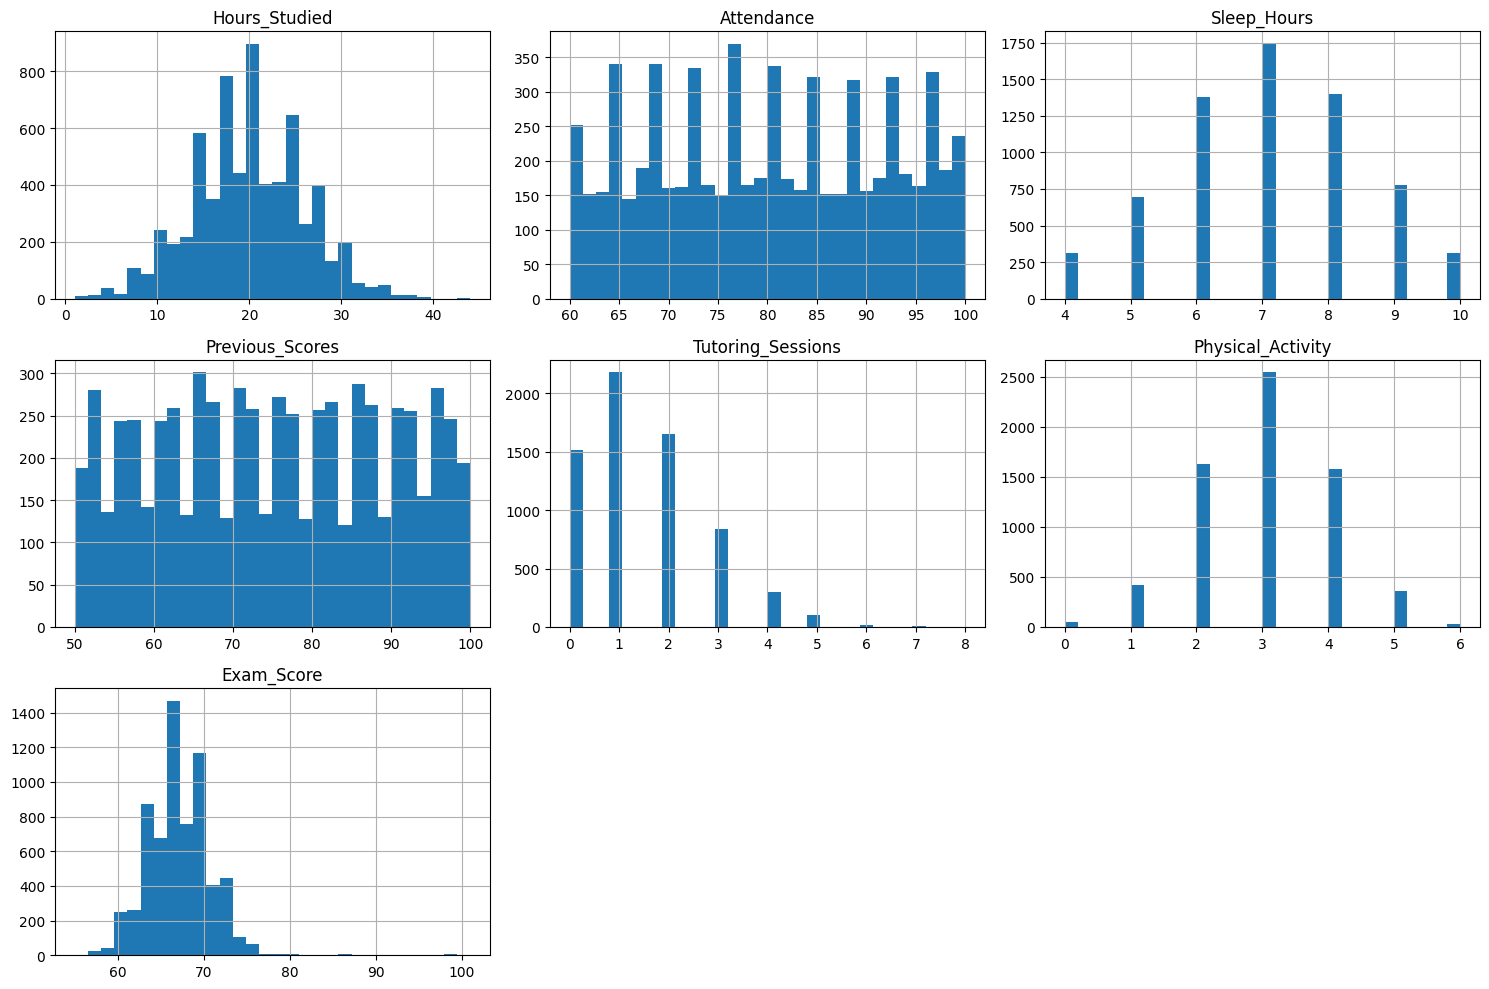

In [17]:
# Visualization of the distribution of all numeric features
student_data[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

📊 Quick Insights from the Histogram

1. Hours_Study

    Normal distribution (bell-shaped).
    ➡ The majority of students study around 15–25 hours.
    There are not many extremes.

2. Attendance

    Fairly evenly distributed between 60–100 hours.
    ➡ Many students have high attendance.
    This is good for the model because the variation is clear.

3. Sleep_Hours

    Concentrated at 6–8 hours.
    ➡ Small variation → it's natural that the effect on grades is small.

4. Previous_Scores

    Relatively evenly distributed between 50–100 hours.
    ➡ Not too skewed, quite stable as a predictor.

5. Tutoring_Sessions

    The majority are in 0–2 sessions.
    Few scores reach 5+.
    ➡ Data is slightly right-skewed.

6. Physical_Activity

    Concentrated at 2–4.
    ➡ Not much extreme variation.

7. Exam_Score

    Majority scores are between 60–75.
    Few are very high (>85).
    ➡ Distribution is fairly normal, not too skewed.

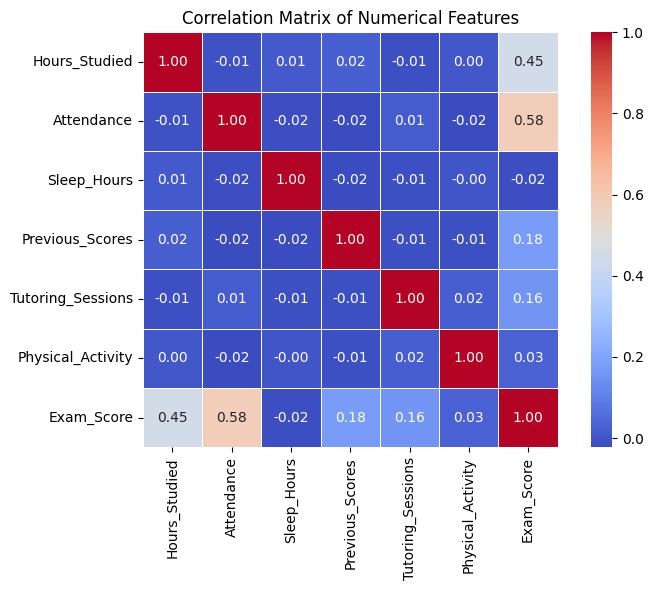

In [18]:
# Correlation of Numerical by Matrix
num_data = student_data[num_cols]
corr = num_data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

Based on the correlation analysis, Attendance and Hours Studied had the strongest positive linear relationship with exam scores, with coefficients of 0.58 and 0.45, respectively. Meanwhile, Sleep Hours and Physical Activity showed very low and insignificant correlations. Furthermore, no multicollinearity was found among the independent variables, thus the regression model used can be considered stable and reliable.

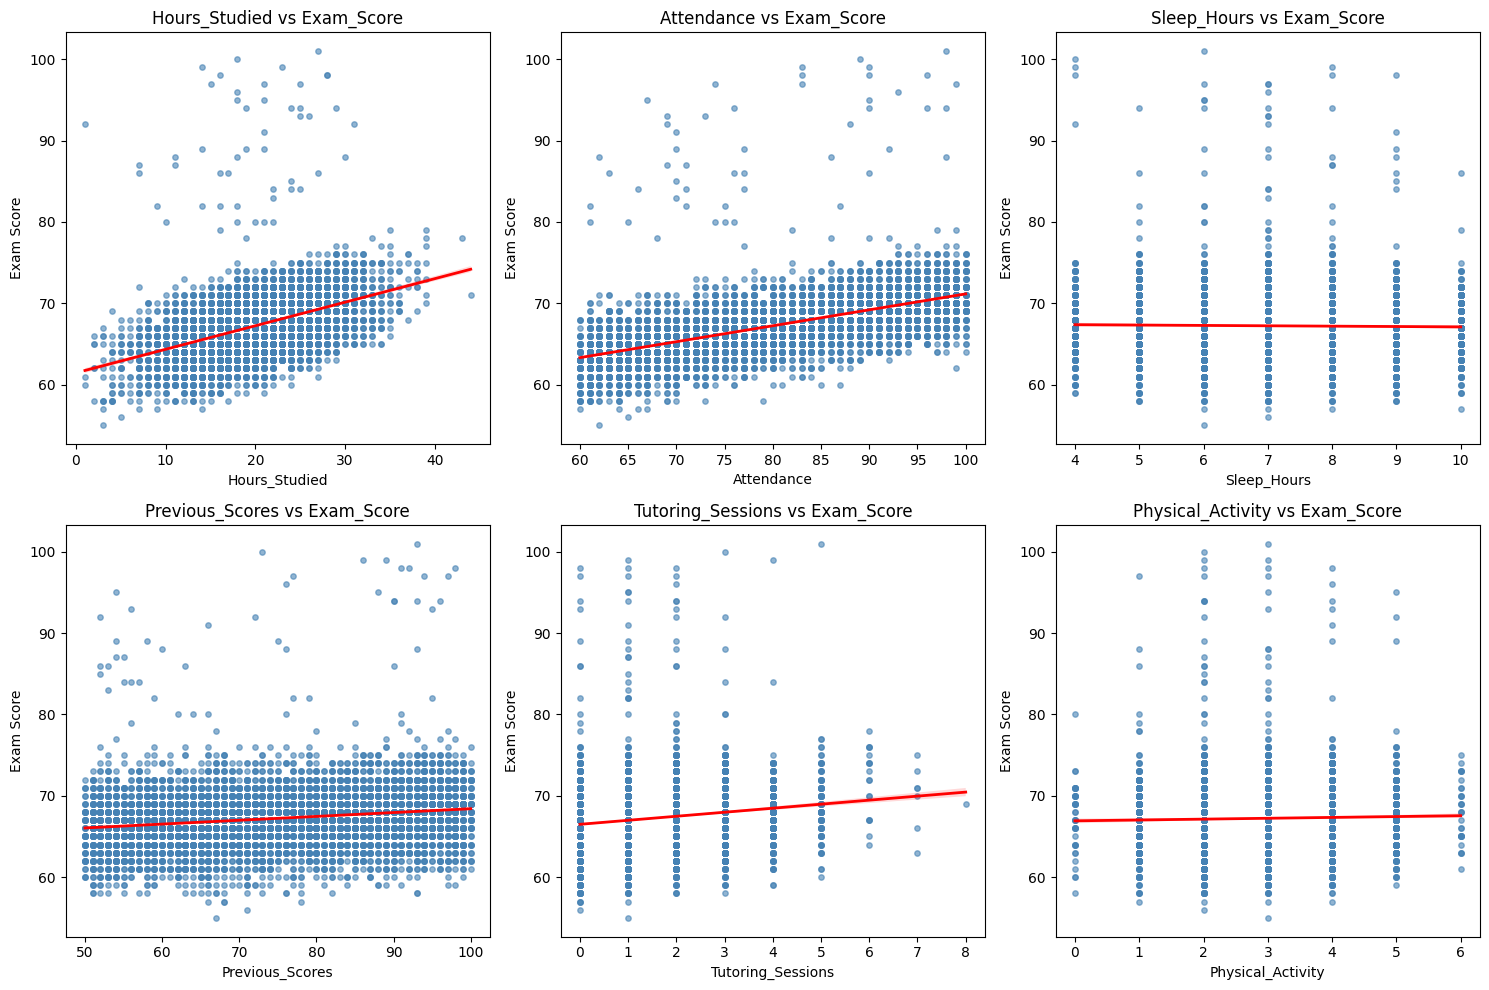

In [19]:
import math

plot_cols = [col for col in num_cols if col != 'Exam_Score']

# Grid Layout
n_cols = 3
n_rows = math.ceil(len(plot_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

# Loop feature
for i, col in enumerate(plot_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.regplot(
        x = student_data[col],
        y = student_data['Exam_Score'],
        scatter_kws = {'s':15, 'alpha':0.6, 'color':'steelblue'},
        line_kws = {'color':'red', 'linewidth':2}

    )

    plt.title(f"{col} vs Exam_Score")
    plt.xlabel(col)
    plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

📊 Insight from Scatter Plot + Regression Line

1. Hours_Studied vs Exam_Score

    🔴 The uptrend line is quite clear

    🔵 The dots are spread out but form a positive pattern

    Insight:
    The more hours of study, the higher the test scores.


2. Attendance vs Exam_Score

    🔴 The upward trend line is clear

    🔵 The pattern is quite neat

    Insight:
    Attendance has a positive linear relationship with exam scores.
    Students with 90–100% attendance tend to have higher grades.

3. Sleep_Hours vs Exam_Score

    🔴 Almost flat line

    🔵 Dots spread out without a clear pattern

    Insight:
    Sleep hours did not show a significant relationship with test scores.

4. Previous_Scores vs Exam_Score

    🔴 Mild positive trend

    🔵 Spread pattern

    Insight:
    Previous grades had a positive relationship, but not as strong as attendance or study hours.
    Indicates the presence of: Academic consistency effect

5. Tutoring_Sessions vs Exam_Score

    🔴 Tren naik tipis

    🔵 Pola tidak terlalu kuat

    Insight:

    Tutoring has an effect, but the effect is moderate. Tutoring helps
    But it's not a dominant factor

6. Physical_Activity vs Exam_Score

    🔴 Almost flat

    🔵 No clear pattern

    Insight:
    Physical activity did not show a significant effect on scores.

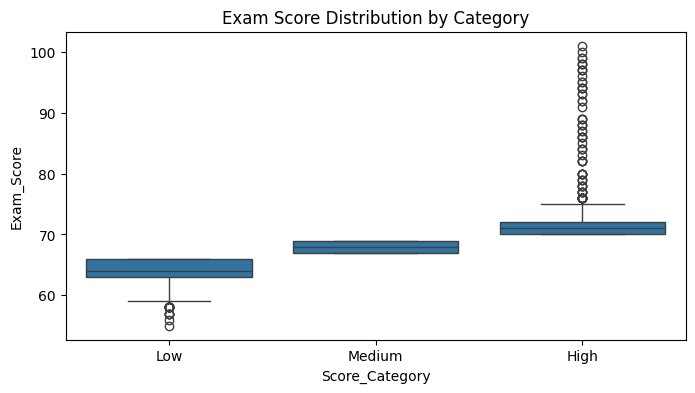

In [20]:
# Create value categories
student_data['Score_Category'] = pd.qcut(
    student_data['Exam_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Boxplot categories
plt.figure(figsize=(8,4))
sns.boxplot(x='Score_Category', y='Exam_Score', data=student_data)
plt.title("Exam Score Distribution by Category")
plt.show()


Based on the boxplot of the test score distribution, the Low, Medium, and High categories show a clear distribution separation, with a consistently increasing median. Variability within each category is relatively small, and there is no significant overlap between classes. This indicates a valid categorization process and facilitates the model's accurate class differentiation.

In [21]:
# Binning Target
student_data['Score_Category'] = pd.qcut(
    student_data['Exam_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

student_data['Score_Category'].value_counts()

,count
Score_Category,
Low,2882
Medium,2100
High,1625


## Anova Test

ANOVA is used to measure whether a numerical feature has a significant influence on the target.

In [22]:
from scipy.stats import f_oneway

anova_results = []

for col in num_cols:
    if col != 'Exam_Score':
      anov_data = student_data[[col, 'Exam_Score']].dropna()
      anov_data['bin'] = pd.qcut(anov_data[col], q = 4, duplicates = 'drop')
      groups = [anov_data[anov_data['bin'] == b]['Exam_Score'] for b in anov_data['bin'].unique()]

      if len(groups) >= 2:
          f_stat, p_val = f_oneway(*groups)
          anova_results.append([col, f_stat, p_val, p_val < 0.05])

anova_std = pd.DataFrame(
    anova_results,
    columns=['Feature', 'F-statistic', 'P-value', 'Significant'])

anova_std = anova_std.sort_values(by='P-value')
anova_std['P-value'] = anova_std['P-value'].apply(lambda x: f"{x:.6f}")
anova_std


,Feature,F-statistic,P-value,Significant
1,Attendance,998.795522,0.000000,True
0,Hours_Studied,469.680145,0.000000,True
3,Previous_Scores,68.815600,0.000000,True
4,Tutoring_Sessions,66.511758,0.000000,True
5,Physical_Activity,2.084291,0.100044,False
2,Sleep_Hours,0.310241,0.818007,False


Based on the ANOVA test, the Attendance and Hours_Studied features have the most significant influence on student performance categories, indicated by a very high F-statistic value and a p-value <0.05. Meanwhile, Physical Activity and Sleep Hours do not show significant differences in average between classes, so their contribution to the classification is relatively low. This indicates that direct academic factors are more dominant than lifestyle factors in determining student performance.


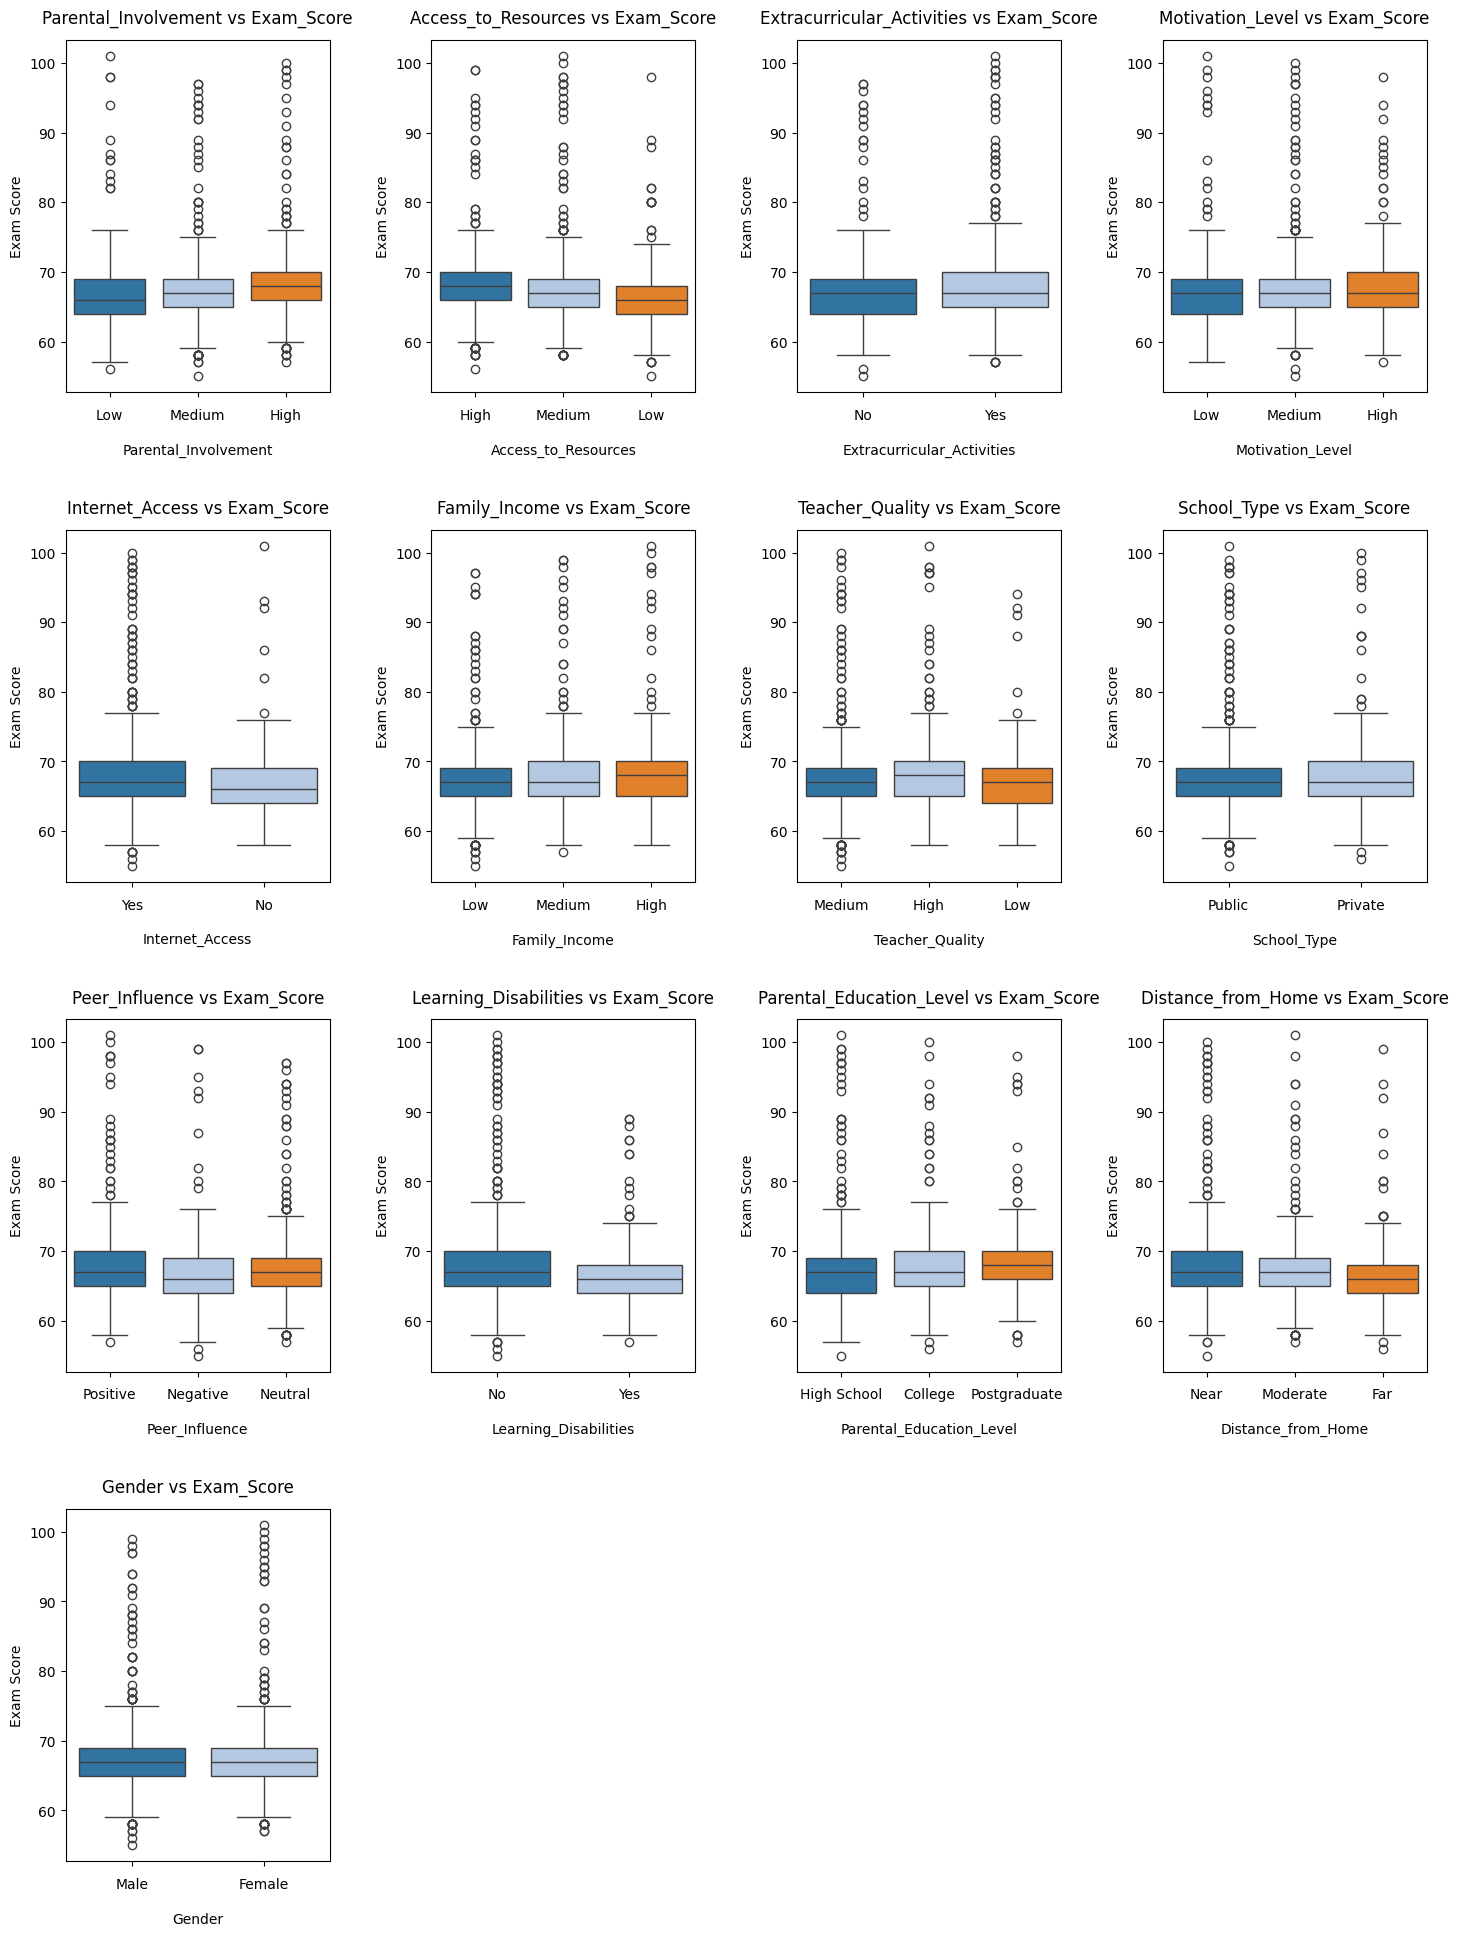

In [23]:
bplot_cols = cat_cols

# Grid layout
n_cols = 4
n_rows = math.ceil(len(bplot_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

# Loop categorical feature
for i, col in enumerate(bplot_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(
        x=student_data[col],
        y=student_data['Exam_Score'],
        hue = student_data[col],
        palette='tab20',
        legend=False,
        ax=ax
    )

    # Title and Label
    ax.set_title(f"{col} vs Exam_Score", pad=12)
    ax.set_xlabel(col, labelpad=15)
    ax.set_ylabel("Exam Score")
    ax.tick_params(axis='x', rotation=0, pad=8)

plt.tight_layout(pad=3)
plt.show()


**MOST INFLUENTIAL FACTORS:**
- Motivation_Level
- Access_to_Resources
- Parental Involvement
- Teacher Quality
- FamilyIncome
- Parental_Education_Level

## Chi - Square Test

In [24]:
from scipy.stats import chi2_contingency

alpha = 0.05 #significance level
chi_results = []

for col in cat_cols:
    contingency = pd.crosstab(student_data[col], student_data['Score_Category'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append([col, chi2, p, p < alpha])

chi_std = pd.DataFrame(chi_results, columns=['Feature', 'Chi2', 'P-value', 'Significant'])
chi_std = chi_std.sort_values(by = 'P-value')
chi_std['P-value'] = chi_std['P-value'].apply(lambda x: f"{x:.6f}")
chi_std

,Feature,Chi2,P-value,Significant
1,Access_to_Resources,217.334746,0.000000,True
0,Parental_Involvement,154.148800,0.000000,True
8,Peer_Influence,77.027072,0.000000,True
10,Parental_Education_Level,66.846600,0.000000,True
11,Distance_from_Home,55.911293,0.000000,True
5,Family_Income,48.385290,0.000000,True
9,Learning_Disabilities,40.499005,0.000000,True
3,Motivation_Level,44.150661,0.000000,True
6,Teacher_Quality,37.718022,0.000000,True
4,Internet_Access,22.848472,0.000011,True


* If p-value < alpha (0.05) → SIGNIFICANT → True
* If p-value ≥ alpha (0.05) → NOT SIGNIFICANT → False

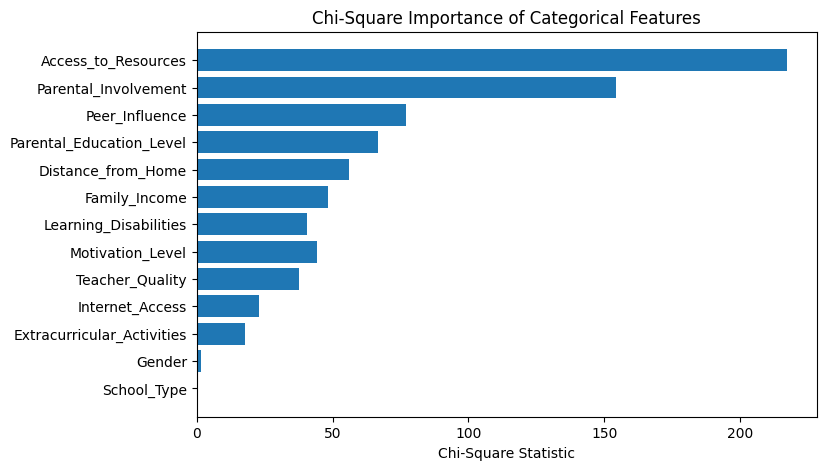

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(chi_std['Feature'], chi_std['Chi2'])
plt.xlabel('Chi-Square Statistic')
plt.title('Chi-Square Importance of Categorical Features')
plt.gca().invert_yaxis()
plt.show()

# 7. Feature Engineering

In [26]:
# Academic Effort Score
# Measuring how much academic effort students put in
student_data['Academic_Effort'] = (
    student_data['Hours_Studied'] * 0.4 +
    student_data['Attendance'] * 0.4 +
    student_data['Tutoring_Sessions'] * 0.2
)

# Learning Momentum
# # Combination of previous performance and learning motivation
lm_map = {'Low': 0.8, 'Medium': 1.0, 'High': 1.2}

student_data['Learning_Momentum'] = (
    student_data['Previous_Scores'] *
    student_data['Motivation_Level'].map(lm_map)
)

# Lifestyle Balance Index
# Measuring life balance (sleep + physical activity)
student_data['Lifestyle_Balance'] = (
    student_data['Sleep_Hours'] * 0.6 +
    student_data['Physical_Activity'] * 0.4
)

# Academic Risk Index
# Academic risk index (the higher the riskier)
student_data['Risk_Index'] = (
    (100 - student_data['Attendance']) * 0.5 +
    (8 - student_data['Sleep_Hours']).clip(lower=0) * 0.3 + (student_data['Motivation_Level']
    .map({'Low':3, 'Medium':2, 'High': 1})) * 0.2
)



In [27]:
pd.set_option('display.max_columns', None)
student_data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Score_Category,Academic_Effort,Learning_Momentum,Lifestyle_Balance,Risk_Index
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium,42.8,58.4,5.4,8.9
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,Low,33.6,47.2,6.4,18.6
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,High,49.2,91.0,5.8,1.7
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,High,47.4,98.0,6.4,5.9
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,High,45.0,65.0,5.2,5.0


# 8. Preprocessing

In [32]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = student_data.drop(columns=["Exam_Score", "Score_Category"])
y = student_data["Score_Category"]

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ]
)


## Generate training and test datasets of dependent and independent variables

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

# Fit
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# to resolve any class imbalance - use stratify parameter.

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)


Shape X_train: (5285, 23)
Shape X_test: (1322, 23)
Shape y_train: (5285,)
Shape y_test: (1322,)


# 9. Model Selection

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score

In [36]:
# Custom scorer untuk Multiclass ROC AUC
def multiclass_roc_auc_score(y_true, y_proba, average="macro"):
    return roc_auc_score(y_true, y_proba, multi_class="ovr", average=average)

roc_auc = make_scorer(multiclass_roc_auc_score, needs_proba=True)

#Using Accuracy and ROC AUC Mean Metrics
models = []
models.append(('Logistic Regression', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=0, class_weight='balanced')))
models.append(('Decision Tree', DecisionTreeClassifier(random_state=0, class_weight='balanced')))
models.append(('Random Forest', RandomForestClassifier(random_state=0, class_weight='balanced')))
models.append(('Gradient Boosting', GradientBoostingClassifier(random_state=0)))
models.append(('KNN', KNeighborsClassifier(n_neighbors=7)))
models.append(('SVM', SVC(kernel='rbf', probability=True, random_state=0, class_weight='balanced')))

# evaluate each model using StratifiedKFold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Evaluating Model Results:
results = []

for name, model in models:
    # Accuracy Dengan CV
    cv_acc_results = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='accuracy')

    # ROC AUC (pakai predict_proba)
    y_proba = cross_val_predict(model, X_train_processed, y_train, cv=cv, method="predict_proba")
    cv_auc_results = roc_auc_score(y_train, y_proba, multi_class="ovr", average="macro")

    results.append([
        name,
        round(cv_auc_results * 100, 2),
        round(cv_acc_results.mean() * 100, 2),
        round(cv_acc_results.std() * 100, 2)
    ])

# set table to table to populate with performance results
col = ['Algorithm', 'ROC AUC Mean', 'Accuracy Mean', 'Accuracy STD']
model_result = pd.DataFrame(results, columns=col)

# sort hasil berdasarkan ROC AUC Mean
model_result = model_result.sort_values(by=['ROC AUC Mean'], ascending=False)

print("\nModel Comparison Results ")
print(model_result)

# Pilih Model Terbaik
best_model_name = model_result.iloc[0]['Algorithm']
best_model = dict(models)[best_model_name]
best_model.fit(X_train_processed, y_train)  # training final dengan semua data train

print(f"\nModel terbaik: {best_model_name}")


Model Comparison Results 
             Algorithm  ROC AUC Mean  Accuracy Mean  Accuracy STD
0  Logistic Regression         98.99          95.02          0.53
5                  SVM         98.22          91.64          1.01
3    Gradient Boosting         95.20          85.18          0.95
2        Random Forest         93.13          80.57          0.92
4                  KNN         88.70          73.55          1.44
1        Decision Tree         78.98          72.85          0.94

Model terbaik: Logistic Regression


Based on the evaluation results of several classifications (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, and KNN), Logistic Regression was found to be the best model for classifying student performance.

## Visualize Classfication Algorithms Accuracy Comparisons

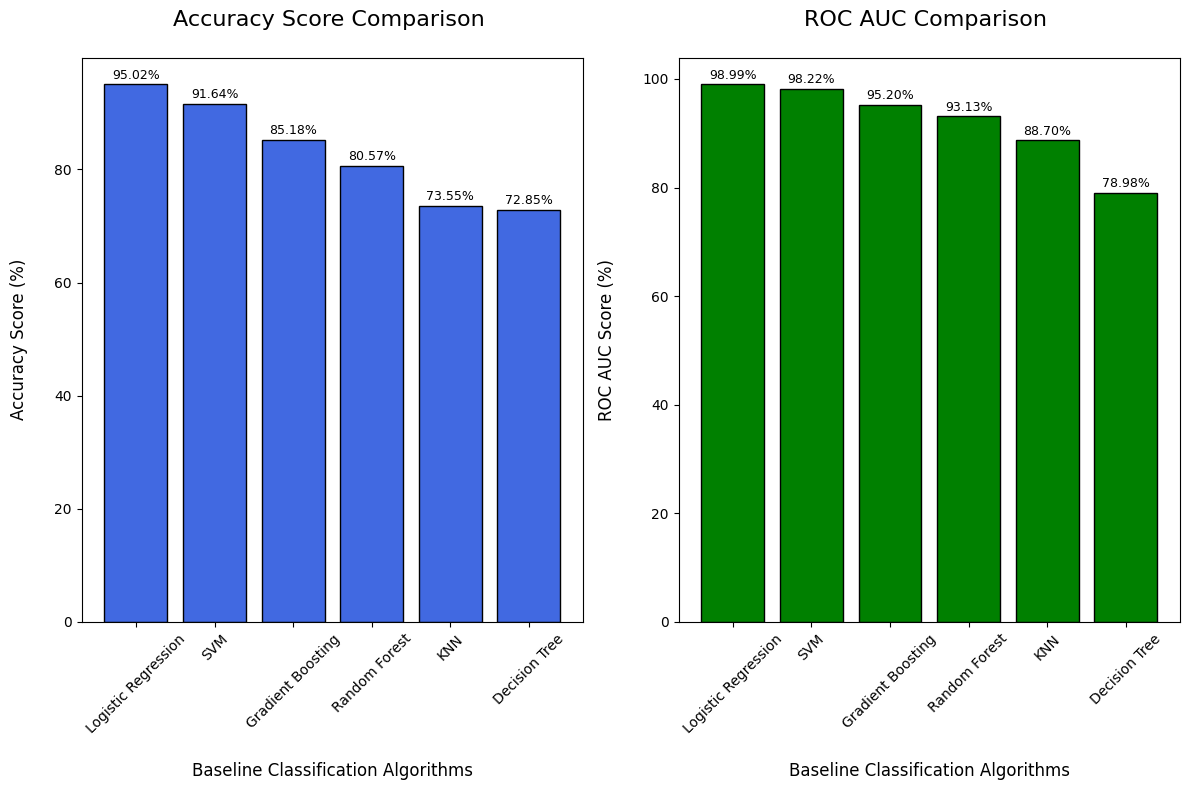

In [37]:
# Step 15.2.  Visualize Classification Algorithms Accuracy Comparisons:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

# Subplot 1 - Accuracy Comparison
bars1 = axes[0].bar(model_result['Algorithm'], model_result['Accuracy Mean'],
                    color='royalblue', edgecolor='black')
axes[0].set_ylabel('Accuracy Score (%)\n', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[0].set_xlabel('\nBaseline Classification Algorithms', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[0].set_title('Accuracy Score Comparison \n', horizontalalignment="center",
                  fontstyle="normal", fontsize=16, fontfamily="sans-serif")
axes[0].tick_params(axis='x', rotation=45)

# persentase bar Accuracy
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

# Subplot 2 - ROC AUC Comparison
bars2 = axes[1].bar(model_result['Algorithm'], model_result['ROC AUC Mean'],
                    color='green', edgecolor='black')
axes[1].set_ylabel('ROC AUC Score (%)\n', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[1].set_xlabel('\nBaseline Classification Algorithms', horizontalalignment="center",
                   fontstyle="normal", fontsize="large", fontfamily="sans-serif")
axes[1].set_title('ROC AUC Comparison \n', horizontalalignment="center",
                  fontstyle="normal", fontsize=16, fontfamily="sans-serif")
axes[1].tick_params(axis='x', rotation=45)

# persentase bar ROC AUC
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**The Logistic Regression model produced the highest Accuracy and ROC AUC
values**. Furthermore, Logistic Regression also excels in interpretability, making it easier to understand and explain in an educational context.

SVM and Gradient Boosting, although more complex, do not provide significant performance improvements, indicating that the data structure tends to be simple and linear.

## Tunning Hyperparameter

In [38]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'class_weight': ['balanced']
}

# Model
lr = LogisticRegression(max_iter=2000, random_state=42)

# Grid Search
grid_search_lr=GridSearchCV(estimator=lr, param_grid=param_grid_lr, cv=5, scoring='accuracy',n_jobs=-1, verbose=2)
grid_search_lr.fit(X_train_processed, y_train)

print("Best Parameters:", grid_search_lr.best_params_)
print("Best CV Accurancy:", grid_search_lr.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Best CV Accurancy: 0.9534531693472091


Hyperparameter tuning using GridSearchCV yielded the best configuration with a C value of 100, L1 penalty, saga solver, and balanced class_weights. This configuration achieved a cross-validation accuracy of 95.35%, indicating the model's excellent generalization capabilities. The use of L1 regularization also aided in the feature selection process, making the model more efficient and robust to noise.

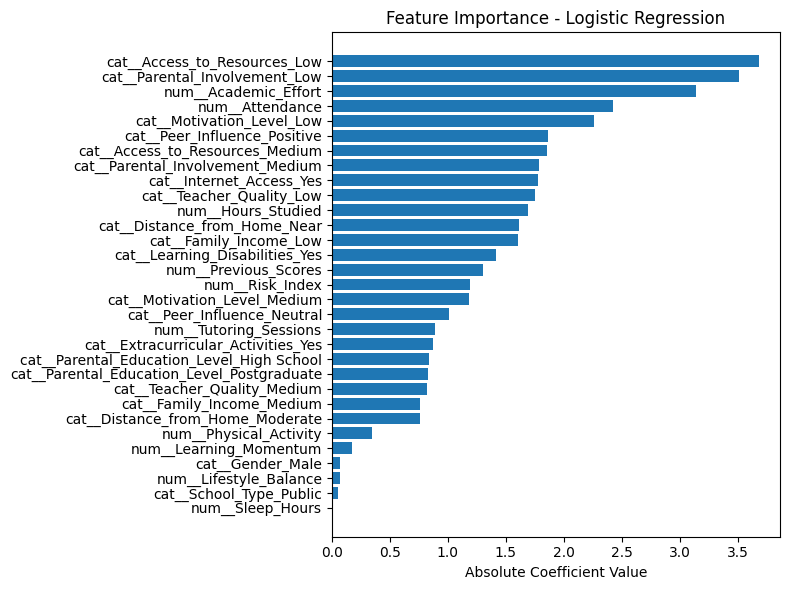

In [42]:
# Train Model
lr = LogisticRegression(C=100, penalty='l1',solver='saga', random_state=42, class_weight='balanced', max_iter=2000)
lr.fit(X_train_processed, y_train)

importance = np.mean(np.abs(lr.coef_), axis=0)

feature_names = preprocessor.get_feature_names_out()

# Visualization
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(8,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Absolute Coefficient Value")
plt.tight_layout()
plt.show()

The model reveals that structural and environmental factors such as access to resources and parental involvement have a stronger impact on student performance than lifestyle-related variables. Academic effort and attendance remain critical predictors, confirming the importance of consistent engagement in learning.

## Check Overvitting Percentage

In [43]:
# Initialize the Logistic Regression model
lr_model = LogisticRegression(C=100, penalty='l1',solver='saga', random_state=42, class_weight='balanced', max_iter=2000)

# Train Model
lr_model.fit(X_train_processed, y_train)

# Train Evaluation
y_train_pred = lr_model.predict(X_train_processed)
y_train_prob = lr_model.predict_proba(X_train_processed)

train_acc = accuracy_score(y_train, y_train_pred)
train_roc = roc_auc_score(y_train, y_train_prob, multi_class="ovr", average='macro')

print('Overfitting Check - Logistic Regression\n')
print('TRAIN SET')
print('Accuracy:', round(train_acc*100, 2), '%')
print('ROC AUC:', round(train_roc*100, 2), '%')

# Test Evaluation
y_test_pred = lr_model.predict(X_test_processed)
y_test_prob = lr_model.predict_proba(X_test_processed)

test_acc = accuracy_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average='macro')

print('\n TEST SET')
print('Accuracy:', round(test_acc*100, 2), '%')
print('ROC AUC:', round(test_roc*100, 2), '%')

#GAP (Overfitting Indicator)
print('\n GAP (Train - Test)')
print('Accuracy GAP:', round((train_acc - test_acc)*100, 2), '%')
print('ROC AUC GAP:', round((train_roc - test_roc)*100, 2), '%')

Overfitting Check - Logistic Regression

TRAIN SET
Accuracy: 95.82 %
ROC AUC: 99.1 %

 TEST SET
Accuracy: 96.6 %
ROC AUC: 99.35 %

 GAP (Train - Test)
Accuracy GAP: -0.78 %
ROC AUC GAP: -0.24 %


Performance on TEST is slightly better than TRAIN.

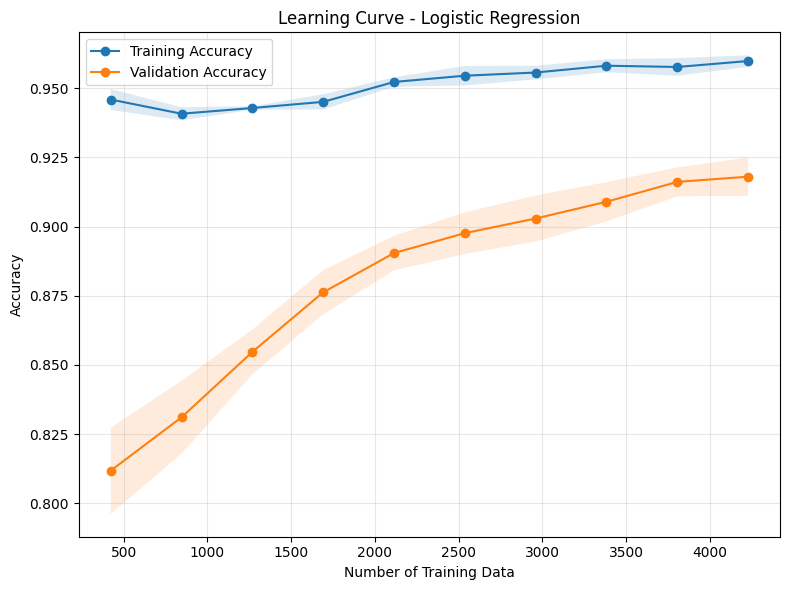

In [44]:
from sklearn.model_selection import learning_curve

# Initialize the Logistic Regression model
lr_model = LogisticRegression(C=100, penalty='l1',solver='saga', random_state=42, class_weight='balanced', max_iter=2000)


# Count learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_processed, y_train,
    cv=5, scoring="accuracy", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Average results
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
test_mean  = np.mean(test_scores, axis=1)
test_std   = np.std(test_scores, axis=1)

# Plot learning curve
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, test_mean, 'o-', label="Validation Accuracy")

plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, alpha=0.15)

plt.xlabel("Number of Training Data")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Logistic Regression")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The learning curve indicates that the Logistic Regression model demonstrates strong generalization capability. As the training data increases, the gap between training and validation accuracy decreases significantly, suggesting reduced variance and improved stability. The model does not exhibit severe overfitting and continues to benefit from additional data.

In [45]:
# 1. Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Fitting Logistic Regression to the Training set
print("\nLogistic Regression")
log_reg = LogisticRegression(C=100, penalty='l1',solver='saga', random_state=42, class_weight='balanced', max_iter=2000)
log_reg.fit(X_train_processed, y_train)

# Predicting the Test set results
y_pred_log = log_reg.predict(X_test_processed)
y_prob_log = log_reg.predict_proba(X_test_processed) # Ambil semua probabilitas kelas

# Evaluate Results
print("Accuracy:", round(accuracy_score(y_test, y_pred_log)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_log, multi_class='ovr', average='macro')*100,2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# 2. Decision Tree
print("\nDecision Tree")
from sklearn.tree import DecisionTreeClassifier

# Fitting Decision Tree to the Training Set:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5)
dt.fit(X_train_processed, y_train)

# Prediciting the Test set results
y_pred_dt = dt.predict(X_test_processed)
y_prob_dt = dt.predict_proba(X_test_processed)

# Evaluate results
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_dt, multi_class='ovr', average='macro')*100,2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

# 3. Random Forest
print("\nRandom Forest")
from sklearn.ensemble import RandomForestClassifier

# Fitting Random Forest to the Training set:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=10)
rf.fit(X_train_processed, y_train)

# Predicting the Test set results
y_pred_rf = rf.predict(X_test_processed)
y_prob_rf = rf.predict_proba(X_test_processed)

# Evaluate Results
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_rf, multi_class='ovr', average='macro')*100,2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))




Logistic Regression
Accuracy: 96.6
ROC AUC: 99.35

Confusion Matrix:
 [[313   3   9]
 [  0 556  21]
 [  9   3 408]]

Classification Report:
               precision    recall  f1-score   support

        High       0.97      0.96      0.97       325
         Low       0.99      0.96      0.98       577
      Medium       0.93      0.97      0.95       420

    accuracy                           0.97      1322
   macro avg       0.96      0.97      0.96      1322
weighted avg       0.97      0.97      0.97      1322


Decision Tree
Accuracy: 72.24
ROC AUC: 88.77

Confusion Matrix:
 [[246   5  74]
 [  2 426 149]
 [ 81  56 283]]

Classification Report:
               precision    recall  f1-score   support

        High       0.75      0.76      0.75       325
         Low       0.87      0.74      0.80       577
      Medium       0.56      0.67      0.61       420

    accuracy                           0.72      1322
   macro avg       0.73      0.72      0.72      1322
weighted avg  

In [46]:
#   4. Gradient Boosting
print("\nGradient Boosting")
gb = GradientBoostingClassifier(random_state=0)
gb.fit(X_train_processed, y_train)  # SMOTE sudah dilakukan pada train

y_pred_gb = gb.predict(X_test_processed)
y_prob_gb = gb.predict_proba(X_test_processed)

print("Accuracy:", round(accuracy_score(y_test, y_pred_gb)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_gb, multi_class='ovr', average='macro')*100,2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

#   5. Support Vector Machine

print("\nSupport Vector Machine")
svm = SVC(probability=True, random_state=0, class_weight='balanced', kernel='rbf')
svm.fit(X_train_processed, y_train)

y_pred_svm = svm.predict(X_test_processed)
y_prob_svm = svm.predict_proba(X_test_processed)

print("Accuracy:", round(accuracy_score(y_test, y_pred_svm)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_svm, multi_class='ovr', average='macro')*100,2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


#   6. K-Nearest Neighbors
print("\nK-Nearest Neighbors")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed, y_train)

y_pred_knn = knn.predict(X_test_processed)
y_prob_knn = knn.predict_proba(X_test_processed)

print("Accuracy:", round(accuracy_score(y_test, y_pred_knn)*100,2))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob_knn, multi_class='ovr', average='macro')*100,2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))



Gradient Boosting
Accuracy: 87.22
ROC AUC: 96.29

Confusion Matrix:
 [[277   3  45]
 [  0 531  46]
 [ 24  51 345]]

Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.85      0.88       325
         Low       0.91      0.92      0.91       577
      Medium       0.79      0.82      0.81       420

    accuracy                           0.87      1322
   macro avg       0.87      0.86      0.87      1322
weighted avg       0.87      0.87      0.87      1322


Support Vector Machine
Accuracy: 92.74
ROC AUC: 98.76

Confusion Matrix:
 [[302   2  21]
 [  0 535  42]
 [ 21  10 389]]

Classification Report:
               precision    recall  f1-score   support

        High       0.93      0.93      0.93       325
         Low       0.98      0.93      0.95       577
      Medium       0.86      0.93      0.89       420

    accuracy                           0.93      1322
   macro avg       0.92      0.93      0.93      1322
weight

## Visualize the results and compare the baseline algorithms


Model Comparison Results (Multiclass):
                 Model  Accuracy  ROC AUC  Precision  Recall  F1 Score  \
0  Logistic Regression     96.60    99.35      96.43   96.60     96.50   
4                  SVM     92.74    98.76      92.46   92.75     92.54   
3    Gradient Boosting     87.22    96.29      87.31   86.47     86.83   
2        Random Forest     82.75    94.24      82.32   82.12     82.19   
1        Decision Tree     72.24    88.77      72.73   72.30     72.14   
5                  KNN     72.01    88.49      70.55   71.26     70.84   

   F2 Score  
0     96.57  
4     92.69  
3     86.64  
2     82.16  
1     72.39  
5     71.12  


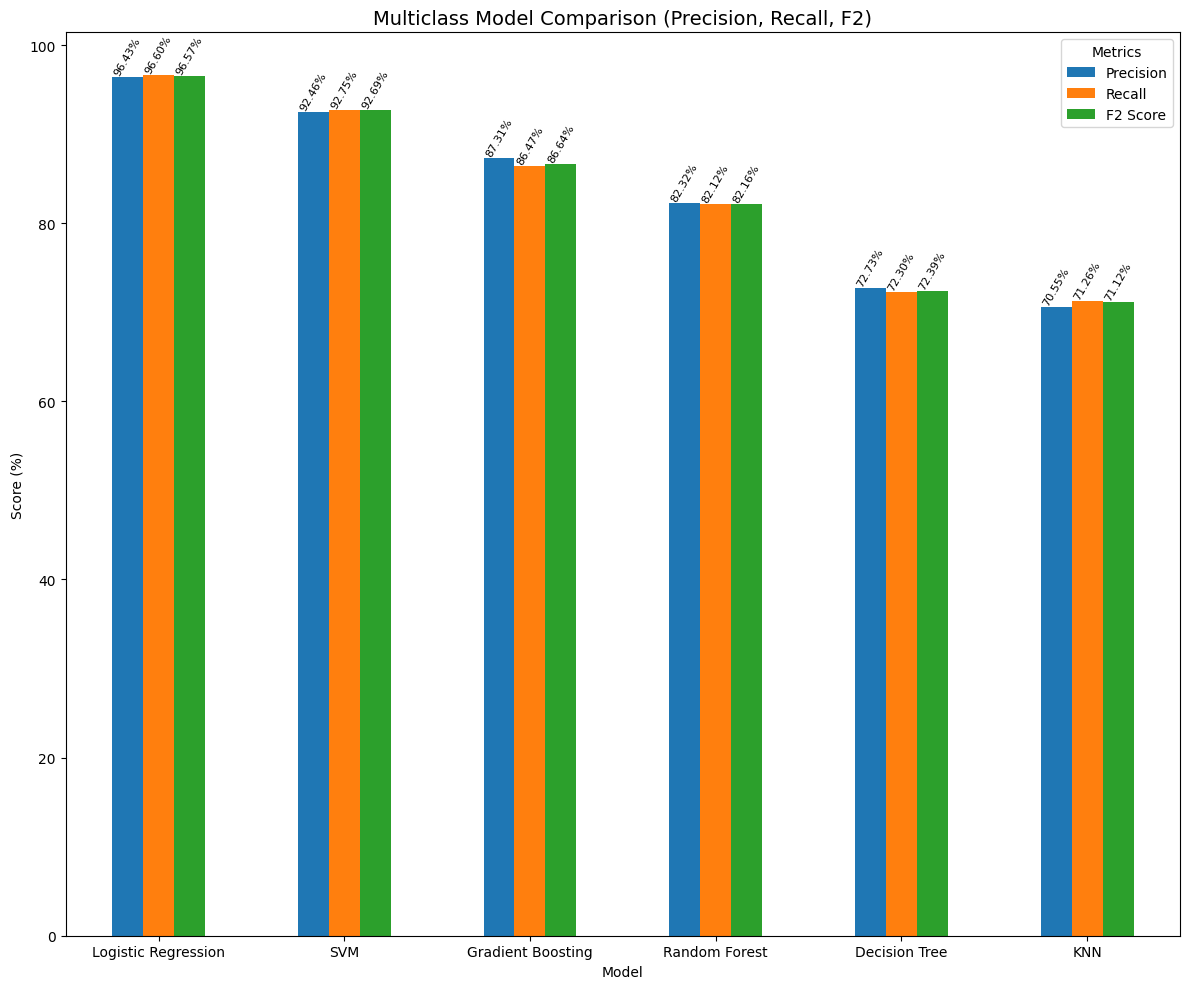

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to compute metrics + F2 Score (macro average)
def evaluate_model(name, y_test, y_pred, y_prob):
    acc = round(accuracy_score(y_test, y_pred)*100, 2)
    roc = round(roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")*100, 2)

    # Macro average so that all classes are treated equally
    prec = round(precision_score(y_test, y_pred, average="macro")*100, 2)
    rec = round(recall_score(y_test, y_pred, average="macro")*100, 2)
    f1 = round(f1_score(y_test, y_pred, average="macro")*100, 2)

    # F2 score for multiclass → calculated manually using a macro formula
    f2 = round(((5 * prec * rec) / ((4 * prec) + rec + 1e-9)), 2)

    return [name, acc, roc, prec, rec, f1, f2]

# Collect results
results_list = []

results_list.append(evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log))
results_list.append(evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt))
results_list.append(evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf))
results_list.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb))
results_list.append(evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm))
results_list.append(evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn))

# Result DataFrame
results_df = pd.DataFrame(results_list,
                             columns=["Model", "Accuracy", "ROC AUC", "Precision", "Recall", "F1 Score", "F2 Score"])

# Sort by Recall and F2 (important for multiclass imbalance)
results_df = results_df.sort_values(["Recall", "F2 Score"], ascending=False)

print("\nModel Comparison Results (Multiclass):")
print(results_df)

# Visualization
ax = results_df.set_index("Model")[["Precision", "Recall", "F2 Score"]].plot(
    kind="bar", figsize=(12, 10))

plt.title("Multiclass Model Comparison (Precision, Recall, F2)", fontsize=14)
plt.ylabel("Score (%)")
plt.xticks(rotation=0)
plt.legend(title="Metrics")

# Tambahkan label persentase di atas setiap bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        label_type='edge',
        fontsize=8,
        rotation=60
    )

plt.tight_layout()
plt.show()

Logistic Regression performed best with 96.43% Precision, 96.66% Recall, and 96.57% F2 Score, making it the most stable and balanced model in classifying student performance categories.

SVM came in second with 92.46% Precision, 92.75% Recall, and 92.69% F2 Score, about 4% lower than Logistic Regression across all metrics.

Gradient Boosting came in third with 87.31% Precision, 86.47% Recall, and 86.64% F2 Score, or about 9–10% lower than Logistic Regression.

In [48]:
# Train & Evaluate Chosen Model
# Fit Chosen Model on The Training dataset
chosen_model = LogisticRegression(C=100, penalty='l1',solver='saga', random_state=42, class_weight='balanced', max_iter=2000)

chosen_model.fit(X_train_processed, y_train)

# Predict the results
y_pred = chosen_model.predict(X_test_processed)
y_prob = chosen_model.predict_proba(X_test_processed)

# Evaluate Model Result on The Set:
print("--- Logistic Regression Evaluation ---")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'))

--- Logistic Regression Evaluation ---
Confusion Matrix:
[[313   3   9]
 [  0 556  21]
 [  9   3 408]]

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.96      0.97       325
         Low       0.99      0.96      0.98       577
      Medium       0.93      0.97      0.95       420

    accuracy                           0.97      1322
   macro avg       0.96      0.97      0.96      1322
weighted avg       0.97      0.97      0.97      1322


Accuracy: 0.9659606656580938
ROC AUC: 0.9934798797879493


Based on the evaluation results, the Logistic Regression model achieved an accuracy of 96.6% with an ROC AUC value of 0.9935, indicating very high classification performance. Precision, recall, and F1-score values ​​for all classes were above 95%, indicating excellent stability and reliability. Prediction errors were relatively small and mostly occurred in adjacent classes, thus the model is considered suitable for use in a student performance prediction system.

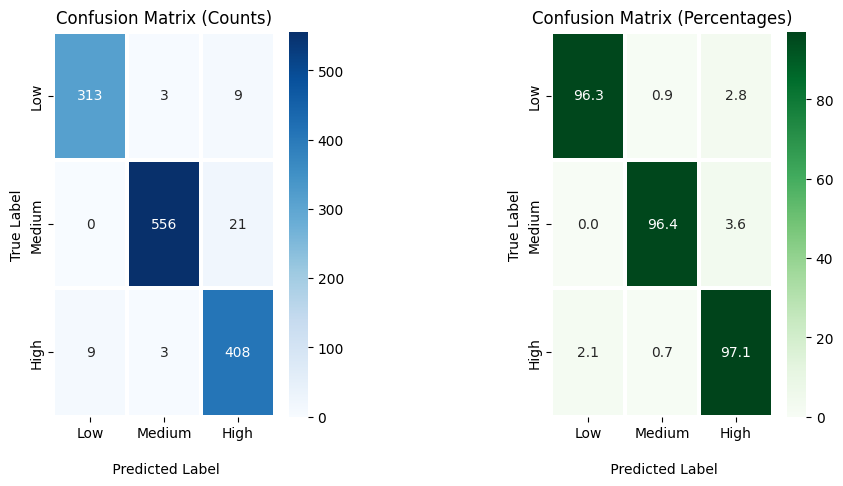

In [49]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
classes = ["Low", "Medium", "High"]

# Persentase
cm_percent = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot 2 heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.8})

# Heatmap Counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            ax=axes[0], linewidths=1.5, linecolor="white")

axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("\n Predicted Label")
axes[0].set_ylabel("True Label")

# Heatmap Percentages
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Greens",
            xticklabels=classes, yticklabels=classes,
            ax=axes[1], linewidths=1.5, linecolor="white")

axes[1].set_title("Confusion Matrix (Percentages)")
axes[1].set_xlabel("\n Predicted Label")
axes[1].set_ylabel("True Label")

plt.show()


The confusion matrix shows that the model is very good at classifying student performance, as evidenced by recall values ​​above 96% for all classes. Classification errors are relatively small, occurring mostly between adjacent classes, particularly from Medium to High. This indicates that the model tends to be slightly optimistic, but overall still demonstrates very stable and reliable performance.

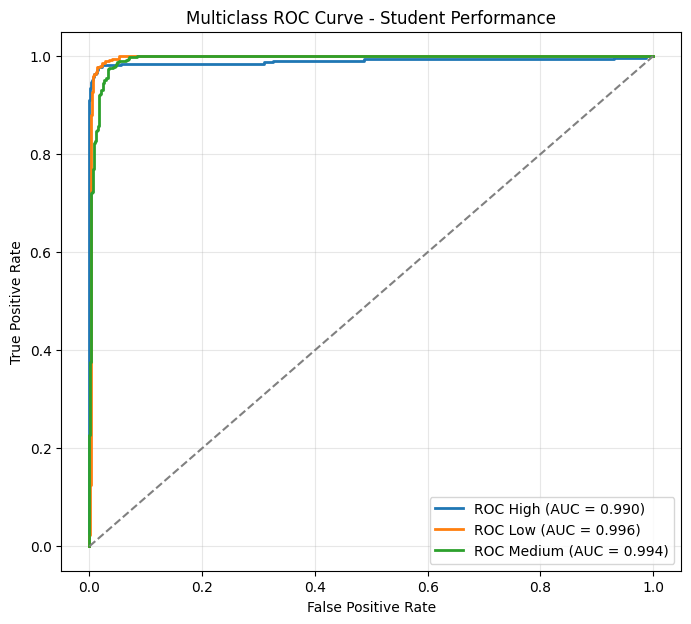

In [50]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

#
classes = np.unique(y_test)

y_test_bin = label_binarize(y_test, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(classes)):
    if y_test_bin[:, i].sum() == 0:
        continue  # skip jika tidak ada sample

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,7))

for i in roc_auc:
    plt.plot(
        fpr[i], tpr[i], lw=2,
        label=f'ROC {classes[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Student Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The model demonstrated excellent classification performance, with AUC values ​​above 0.99 across all classes. The ROC curve, which approaches the upper left corner, indicates the model's ability to accurately distinguish between classes with a very low error rate.

# 10. Polynomial Features

In [51]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_processed)
X_test_poly = poly.transform(X_test_processed)

print("Train polynomial shape:", X_train_poly.shape)
print("Test polynomial shape :", X_test_poly.shape)

lr_poly = LogisticRegression(
    C=100,
    penalty='l1',
    solver='saga',
    random_state=42,
    class_weight='balanced',
    max_iter=2000
)

lr_poly.fit(X_train_poly, y_train)

# 3️⃣ Predict
y_pred_poly = lr_poly.predict(X_test_poly)
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Train polynomial shape: (5285, 527)
Test polynomial shape : (1322, 527)
Confusion Matrix:

[[313   3   9]
 [  0 556  21]
 [  9   3 408]]

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.96      0.97       325
         Low       0.99      0.96      0.98       577
      Medium       0.93      0.97      0.95       420

    accuracy                           0.97      1322
   macro avg       0.96      0.97      0.96      1322
weighted avg       0.97      0.97      0.97      1322



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [52]:
# Initialize the Logistic Regression model
lr_poly = LogisticRegression(
    C=100,
    penalty='l1',
    solver='saga',
    random_state=42,
    class_weight='balanced',
    max_iter=2000
)

# Train Model
lr_poly.fit(X_train_poly, y_train)

# Train Evaluation
y_train_pred = lr_poly.predict(X_train_poly)
y_train_prob = lr_poly.predict_proba(X_train_poly)

train_acc = accuracy_score(y_train, y_train_pred)
train_roc = roc_auc_score(y_train, y_train_prob, multi_class="ovr", average='macro')

print('Overfitting Check - Logistic Regression\n')
print('TRAIN SET')
print('Accuracy:', round(train_acc*100, 2), '%')
print('ROC AUC:', round(train_roc*100, 2), '%')

# Test Evaluation
y_test_pred = lr_poly.predict(X_test_poly)
y_test_prob = lr_poly.predict_proba(X_test_poly)

test_acc = accuracy_score(y_test, y_test_pred)
test_roc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average='macro')

print('\n TEST SET')
print('Accuracy:', round(test_acc*100, 2), '%')
print('ROC AUC:', round(test_roc*100, 2), '%')

#GAP (Overfitting Indicator)
print('\n GAP (Train - Test)')
print('Accuracy GAP:', round((train_acc - test_acc)*100, 2), '%')
print('ROC AUC GAP:', round((train_roc - test_roc)*100, 2), '%')

Overfitting Check - Logistic Regression

TRAIN SET
Accuracy: 99.02 %
ROC AUC: 99.95 %

 TEST SET
Accuracy: 91.07 %
ROC AUC: 98.09 %

 GAP (Train - Test)
Accuracy GAP: 7.94 %
ROC AUC GAP: 1.86 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Adding Polynomial Features (degree=2) significantly increased training accuracy (99.62%) but reduced generalization performance on the test set (90.54%), indicating overfitting. Therefore, the linear Logistic Regression model without polynomial transformation provides a better bias-variance balance for this dataset.

# 11. Interpretability Model with SHAP

SHAP is an explainable AI method for describing the contribution of each feature to a model's prediction.

With SHAP, we can determine:
* Which features are most influential
* The direction of the feature's influence (increasing/decreasing predictions)
* Why the model selected a particular class

In [53]:
!pip install shap

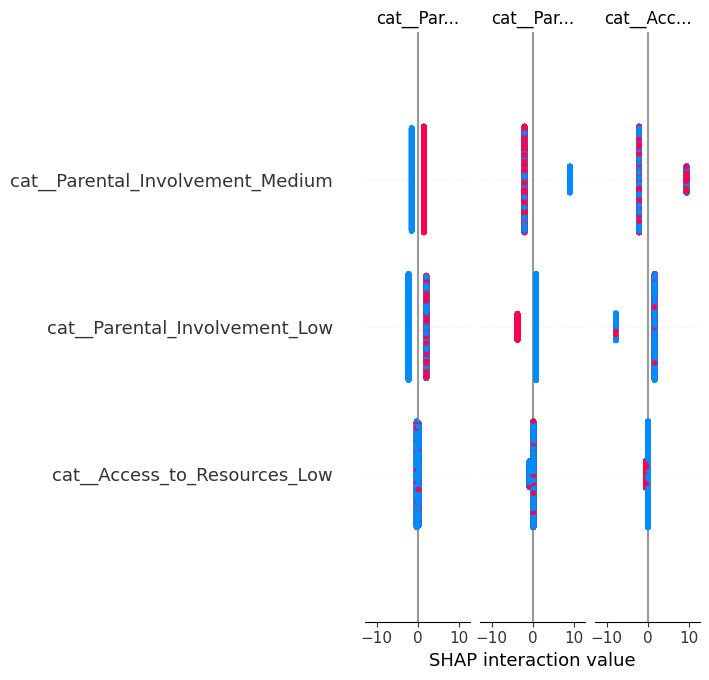

In [56]:
import shap

# Fit Logistic Regression Model
best_lr = LogisticRegression(C=100, penalty='l1',solver='saga', random_state=42, class_weight='balanced', max_iter=2000)
best_lr.fit(X_train_processed, y_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Convert into Dataframe
X_train_processed_std = pd.DataFrame(X_train_processed, columns=feature_names)

# Explainer
explainer = shap.LinearExplainer(best_lr, X_train_processed_std)

# SHAP Values
shap_values = explainer.shap_values(X_train_processed_std)

# Summary plot
shap.summary_plot(shap_values, X_train_processed_std)

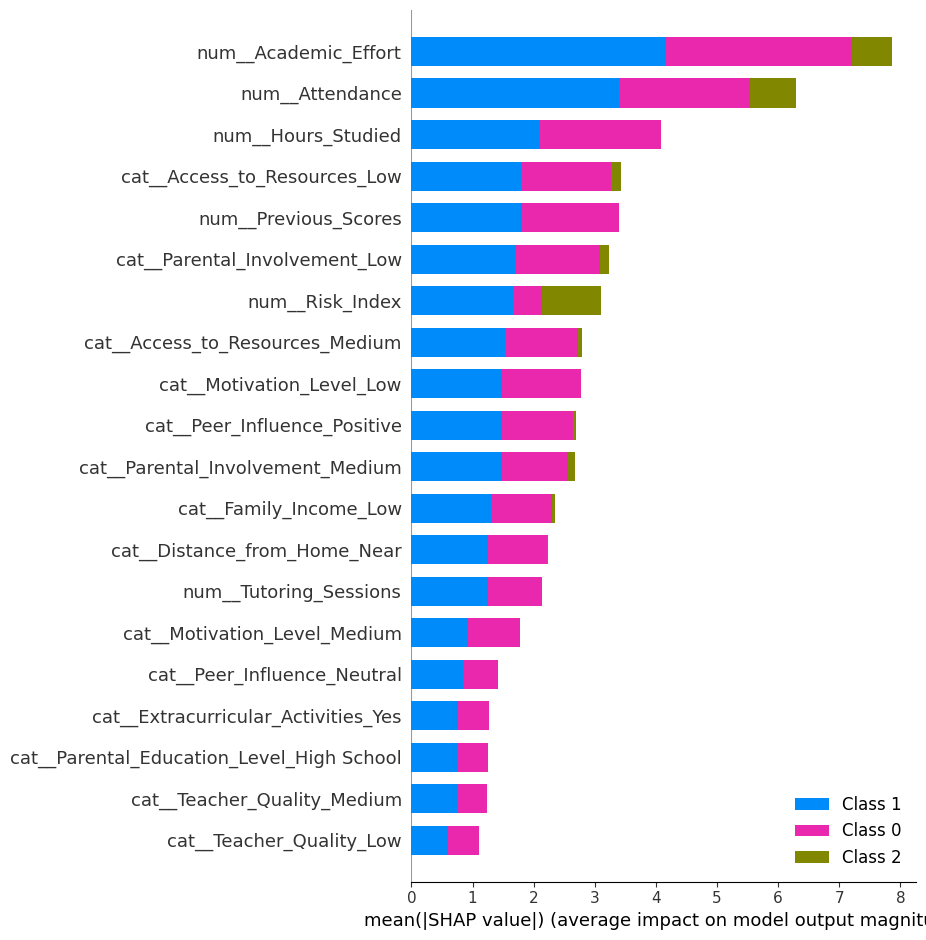

In [57]:
plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_train_processed_std, plot_type='bar', show=False)
plt.subplots_adjust(left=0.35)
plt.show()


🎯 Policy Recommendations (Based on SHAP Findings)

1. Attendance
    -  Implementation of an early warning-based attendance monitoring system
    - Rapid intervention for students with high absenteeism

2. Academic Effort & Study Hours
    - Study habits coaching program
    - Time management and learning effectiveness workshops

3. Previous Scores
    - Remedial program based on previous performance
    - Early academic intervention for at-risk students

4. Access to Learning Resources

    - Provision of textbook assistance & access to digital learning
    - Study support program for students with limited access

5. Parental Involvement

    - Parent engagement program
    - Education on the role of parents in supporting the learning process

---

**📊 Business Insight**

To improve student academic performance, schools need to prioritize:

 - Improving attendance discipline
 - Optimizing learning hours and quality
 - Remedial programs based on previous grades
 - Increasing access to learning resources
 - Strengthening parental support

In conclusion, interventions based on study habits and environmental support will have the greatest impact on improving student performance compared to demographic factors alone.

In [58]:
import sklearn
import numpy
import pandas
import joblib
import seaborn
import matplotlib
import plotly

print("Library version:")
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)
print("seaborn:", seaborn.__version__)
print("matplotlib:", matplotlib.__version__)
print("plotly:", plotly.__version__)
print("-"*50)


Library version:
scikit-learn: 1.6.1
numpy: 2.0.2
pandas: 2.2.2
joblib: 1.5.3
seaborn: 0.13.2
matplotlib: 3.10.0
plotly: 5.24.1
--------------------------------------------------


In [59]:
# Save Model & Scaler
import joblib

joblib.dump(lr_poly, "/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/StudentPerformanceFactors/poly_model.pkl")
joblib.dump(chosen_model, "/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/StudentPerformanceFactors/lr_model.pkl")
joblib.dump(preprocessor, "/content/drive/MyDrive/Data Enthusiast Project/Elevvo Internship - ML/StudentPerformanceFactors/preprocessor.pkl")
print("Model dan scaler berhasil disimpan!")

Model dan scaler berhasil disimpan!
